# Chi-Square Test of Independence

The **chi-square test of independence** determines whether two categorical variables are associated or independent. It compares observed cell frequencies to the expected frequencies under the assumption of independence.

| Property | Value |
|---|---|
| **H₀** | The two variables are independent |
| **H₁** | The two variables are associated |
| **Test statistic** | χ² = Σ (O − E)² / E |
| **df** | (r−1)(c−1) where r=rows, c=columns |
| **Expected** | E_ij = (row total_i × col total_j) / N |
| **Assumption** | E_ij ≥ 5 for all cells (use Fisher's exact if violated) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

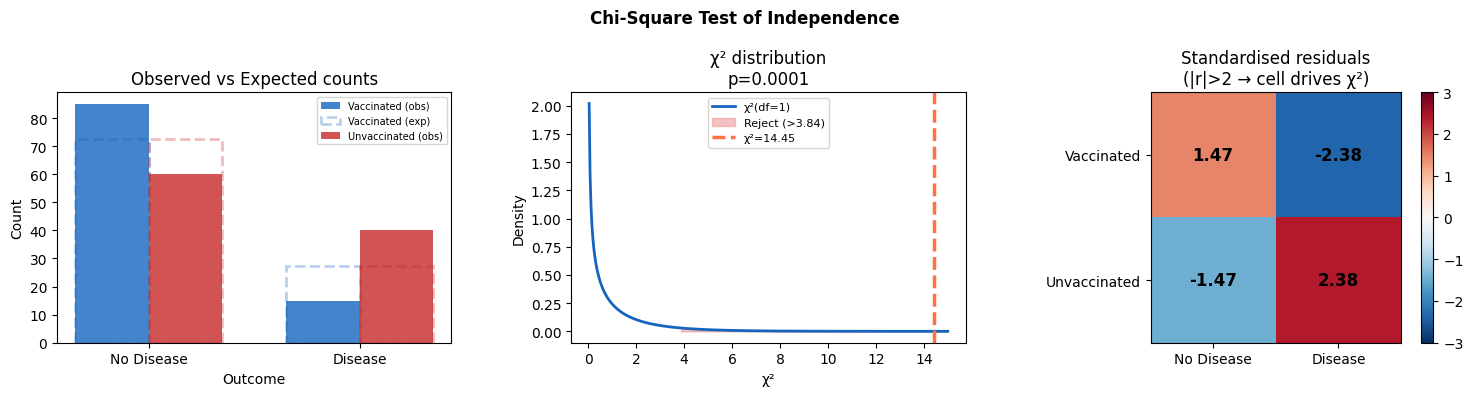

Chi-square=14.4451, df=1, p=0.0001
Observed:
[[85 15]
 [60 40]]
Expected:
[[72.5 27.5]
 [72.5 27.5]]
Cramér's V (effect size) = 0.269


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Chi-Square Test of Independence', fontsize=12, fontweight='bold')

# Observed contingency table (vaccine × outcome)
obs = np.array([[85, 15],   # Vaccinated: 85 no disease, 15 disease
                [60, 40]])  # Unvaccinated: 60 no, 40 disease
row_labels = ['Vaccinated', 'Unvaccinated']
col_labels = ['No Disease', 'Disease']

chi2, p_val, dof, expected = stats.chi2_contingency(obs)
N = obs.sum()
row_totals = obs.sum(axis=1)
col_totals = obs.sum(axis=0)

# Panel 1: observed vs expected bars
x = np.arange(len(col_labels))
width = 0.35
for i, (row_label, color) in enumerate(zip(row_labels, ['#1565C0', '#C62828'])):
    axes[0].bar(x - width/2 + i*width, obs[i], width, color=color, alpha=0.8, label=f'{row_label} (obs)')
    axes[0].bar(x - width/2 + i*width, expected[i], width, color=color, alpha=0.3,
                edgecolor=color, linestyle='--', linewidth=2, fill=False, label=f'{row_label} (exp)' if i==0 else '')
axes[0].set_title('Observed vs Expected counts')
axes[0].set_xlabel('Outcome'); axes[0].set_ylabel('Count')
axes[0].set_xticks(x); axes[0].set_xticklabels(col_labels)
axes[0].legend(fontsize=7)

# Panel 2: chi-square distribution
chi2_range = np.linspace(0, 15, 400)
chi2_pdf = stats.chi2.pdf(chi2_range, dof)
chi2_crit = stats.chi2.ppf(0.95, dof)
axes[1].plot(chi2_range, chi2_pdf, color='#1565C0', lw=2, label=f'χ²(df={dof})')
axes[1].fill_between(chi2_range, chi2_pdf, where=chi2_range >= chi2_crit,
                     color='#EF9A9A', alpha=0.6, label=f'Reject (>{chi2_crit:.2f})')
axes[1].axvline(chi2, color='#FF7043', lw=2.5, ls='--', label=f'χ²={chi2:.2f}')
axes[1].set_title(f'χ² distribution\np={p_val:.4f}')
axes[1].set_xlabel('χ²'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# Panel 3: residuals (Pearson standardised)
residuals = (obs - expected) / np.sqrt(expected)
im = axes[2].imshow(residuals, cmap='RdBu_r', vmin=-3, vmax=3)
axes[2].set_xticks(range(len(col_labels))); axes[2].set_xticklabels(col_labels)
axes[2].set_yticks(range(len(row_labels))); axes[2].set_yticklabels(row_labels)
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{residuals[i,j]:.2f}', ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[2])
axes[2].set_title('Standardised residuals\n(|r|>2 → cell drives χ²)')

plt.tight_layout(); plt.show()
print(f'Chi-square={chi2:.4f}, df={dof}, p={p_val:.4f}')
print(f'Observed:\n{obs}')
print(f'Expected:\n{expected.round(1)}')
cramer_v = np.sqrt(chi2 / (N * min(obs.shape[0]-1, obs.shape[1]-1)))
print(f"Cramér's V (effect size) = {cramer_v:.3f}")

## Key Takeaways

| | |
|---|---|
| **χ² = Σ(O−E)²/E** | Large value when observed departs strongly from independent expectation |
| **df = (r−1)(c−1)** | 2×2 table → df=1; 3×3 table → df=4 |
| **E ≥ 5 rule** | If any E_ij < 5, use Fisher's exact test instead |
| **Standardised residuals** | |r| > 2 identifies which cells drive the association |
| **Cramér's V** | Effect size: 0=no association, 1=perfect; good for any table size |
| **Directional** | χ² does not tell direction; inspect residuals or proportions |